# Preliminary Steps
Cleaning the data

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import cvxpy as cp

# investment universe
U = ['FXE', 'EWJ', 'GLD', 'QQQ', 'SHV', 'DBA', 'USO', 'XBI', 'ILF', 'EPP', 'FEZ']
market = 'SPY'  # benchmark
tickers = U + [market]

start_date = "2007-03-01"
end_date = "2025-10-31"

# prices
prices = yf.download(tickers, start=start_date, end=end_date)['Close']
prices = prices.dropna()

returns = prices.pct_change().dropna()

# Fama French Factors

ff = pd.read_csv(
    "/content/F-F_Research_Data_Factors_daily.csv",
    skiprows=4
)

ff = ff.rename(columns={ff.columns[0]: "Date"})  # rename first column to Date
ff["Date"] = pd.to_datetime(ff["Date"], format="%Y%m%d", errors="coerce")  # convert Date to datetime
ff = ff.dropna(subset=["Date"])  # drop rows where the above fails

ff = ff[["Date", "Mkt-RF", "SMB", "HML", "RF"]]  # keep needed columns

ff[["Mkt-RF", "SMB", "HML", "RF"]] = ff[["Mkt-RF", "SMB", "HML", "RF"]] / 100.0  # convert from percent to decimal

ff = ff.set_index("Date").sort_index()  # use date as index

data = returns.join(ff, how="inner")  # only keep overlapping dates
print(data.head())

/tmp/ipython-input-4063372860.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  12 of 12 completed


                 DBA       EPP       EWJ       FEZ       FXE       GLD  \
Date                                                                     
2007-03-02 -0.009384 -0.010886 -0.016338 -0.013193  0.000682 -0.032057   
2007-03-05 -0.001894 -0.030768 -0.014533 -0.017953 -0.007576 -0.012243   
2007-03-06 -0.005315  0.041028  0.023877  0.028394  0.002672  0.019387   
2007-03-07  0.009160 -0.003424 -0.002058 -0.001891  0.004416  0.002338   
2007-03-08 -0.000756  0.012063  0.008935  0.010231 -0.003184  0.002799   

                 ILF       QQQ       SHV       SPY       USO       XBI  \
Date                                                                     
2007-03-02 -0.020606 -0.015071  0.000551 -0.013095 -0.004489 -0.024478   
2007-03-05 -0.022896 -0.007768 -0.000184 -0.009519 -0.027250 -0.008869   
2007-03-06  0.049272  0.016607  0.000091  0.017109  0.014107  0.012222   
2007-03-07 -0.008390 -0.003967  0.000368 -0.001002  0.019277 -0.003881   
2007-03-08  0.020026  0.006795  0.000

# Estimating the Fama-French 3-Factor Model

In [ ]:
import statsmodels.api as sm  # for linear regression

# Estimating Betas
assets = U  # universe without SPY

excess_returns = data[assets].subtract(data["RF"], axis=0)  # for each ETF

F = data[["Mkt-RF", "SMB", "HML"]]  # factor matrix

F_with_const = sm.add_constant(F)  # adding constant term to estimate alpha_i

betas = pd.DataFrame(index=assets, columns=["alpha", "beta_mkt", "beta_smb", "beta_hml"])  # values to be estimated

spec_var = pd.Series(index=assets, dtype=float)  # specific variances (idiosyncratic)

for asset in assets:
    y = excess_returns[asset]
    model = sm.OLS(y, F_with_const).fit()  # linear regression

    betas.loc[asset, "alpha"] = model.params["const"]
    betas.loc[asset, "beta_mkt"] = model.params["Mkt-RF"]
    betas.loc[asset, "beta_smb"] = model.params["SMB"]
    betas.loc[asset, "beta_hml"] = model.params["HML"]

    spec_var[asset] = model.mse_resid  # specific variance

betas = betas.astype(float)  # numeric values

print("\nEstimated Betas (Time-Series French Fama 3-Factor Model):")
print(betas)

# Factor and Return Estimates

# Factor Means and Factor Covariance
mu_f = F.mean()
Omega_f = F.cov()

# Expected ETF Returns (rho_i)
rf_bar = data["RF"].mean()  # average risk-free rate over sample

expected_returns = pd.Series(index=assets, dtype=float)

for asset in assets:
    alpha = betas.loc[asset, "alpha"]
    beta_mkt = betas.loc[asset, "beta_mkt"]
    beta_smb = betas.loc[asset, "beta_smb"]
    beta_hml = betas.loc[asset, "beta_hml"]

    expected_returns[asset] = (
            rf_bar
            + beta_mkt * mu_f["Mkt-RF"]
            + beta_smb * mu_f["SMB"]
            + beta_hml * mu_f["HML"]
            + alpha
    )

print("\nExpected ETF returns rho_i (per day from 3-factor model):")
print(expected_returns)

#  Covariance Matrix (Cross Sectional French Fama 3 Factor Model)

B = betas[["beta_mkt", "beta_smb", "beta_hml"]].values  # matrix of betas

D = np.diag(spec_var.values)  # diagonal matrix of variances

Omega_f_mat = Omega_f.values  # factor covariance

Sigma = B @ Omega_f_mat @ B.T + D  # matrix multiplication (systematic risk + idiosyncratic risk)

Sigma_df = pd.DataFrame(Sigma, index=assets, columns=assets)

print("\nFactor-model covariance matrix:")
print(Sigma_df.head())


Estimated Betas (Time-Series French Fama 3-Factor Model):
        alpha  beta_mkt  beta_smb  beta_hml
FXE -0.000105  0.099742  0.009164  0.014191
EWJ -0.000179  0.776085 -0.068805  0.032520
GLD  0.000341  0.050541  0.030706 -0.112107
QQQ  0.000139  1.074347 -0.051454 -0.395760
SHV  0.000003 -0.003111  0.001634 -0.000272
DBA -0.000072  0.234215 -0.018677  0.060471
USO -0.000405  0.636424 -0.044194  0.434178
XBI  0.000110  1.000695  1.000169 -0.531541
ILF -0.000229  1.200610 -0.092339  0.330181
EPP -0.000177  1.029286 -0.063553  0.152242
FEZ -0.000219  1.090119 -0.063243  0.174686

Expected ETF returns rho_i (per day from 3-factor model):
FXE   -0.000005
EWJ    0.000220
GLD    0.000428
QQQ    0.000701
SHV    0.000059
DBA    0.000084
USO   -0.000098
XBI    0.000620
ILF    0.000335
EPP    0.000325
FEZ    0.000308
dtype: float64

Factor-model covariance matrix:
              FXE           EWJ           GLD           QQQ           SHV  \
FXE  3.259169e-05  1.279806e-05  6.020098e-07  1.6650

# Weekly Backtesting

In [ ]:
# Weekly Rebalancing Dates (every Friday)
rebal_dates = returns.resample('W-FRI').last().index  # split into weekly bins that end on Fridays
rebal_dates = rebal_dates[rebal_dates >= pd.to_datetime("2007-03-01")]

# Lookback Windows
lookbacks_cov = {
    "ST": 60,  # Short-Term ≈ 40–60 days
    "MT": 90,  # Mid-Term
    "LT": 180  # Long-Term
}  # Sigma window
lookbacks_mu = {
    "ST": 60,
    "MT": 90,
    "LT": 180
}  # rho window

term_structure_combos = [
    ("ST", "ST"),
    ("MT", "MT"),
    ("LT", "LT"),
    ("MT", "ST"),
    ("ST", "MT"),
]


# Helper Function (For Calculating Regression Model, Expected Return, and Covariance Matrix)
def compute_factor_model_inputs(window_cov_returns, window_cov_ff, window_mu_returns, window_mu_ff,
                                window_cov_spy=None):
    assets = window_cov_returns.columns

    excess_cov = window_cov_returns.subtract(window_cov_ff["RF"], axis=0)
    F_cov = window_cov_ff[["Mkt-RF", "SMB", "HML"]]
    F_cov_const = sm.add_constant(F_cov)

    # Time-series Regressions
    B_cov = []  # factor betas
    sigma_eps = []  # idiosyncratic variances

    for asset in assets:
        y = excess_cov[asset]
        model = sm.OLS(y, F_cov_const).fit()
        params = model.params
        B_cov.append([params["Mkt-RF"], params["SMB"], params["HML"]])
        sigma_eps.append(model.resid.var())

    B_cov = np.array(B_cov, dtype=float)
    D = np.diag(np.array(sigma_eps, dtype=float))

    # Covariance
    Omega_f = F_cov.cov().values
    Sigma = B_cov @ Omega_f @ B_cov.T + D

    excess_mu = window_mu_returns.subtract(window_mu_ff["RF"], axis=0)
    F_mu = window_mu_ff[["Mkt-RF", "SMB", "HML"]]
    F_const = sm.add_constant(F_mu)

    B_mu = []
    alpha_mu = []

    for asset in assets:
        y = excess_mu[asset]
        model = sm.OLS(y, F_const).fit()
        params = model.params
        alpha_mu.append(params["const"])
        B_mu.append([params["Mkt-RF"], params["SMB"], params["HML"]])

    B_mu = np.array(B_mu, dtype=float)
    alpha_mu = np.array(alpha_mu, dtype=float)

    mu_f = F_mu.mean().values
    rf_t = window_mu_ff["RF"].iloc[-1]
    rho = rf_t + (B_mu @ mu_f) + alpha_mu

    # Beta calculation
    df_b = pd.concat([window_cov_returns, window_cov_spy, window_cov_ff["RF"]], axis=1).dropna()
    spy_col = df_b.columns[-2]
    rf_col = df_b.columns[-1]

    spy_excess = df_b[spy_col] - df_b[rf_col]
    var_spy = spy_excess.var()

    beta = []
    for asset in assets:
        asset_excess = df_b[asset] - df_b[rf_col]
        beta.append(asset_excess.cov(spy_excess) / var_spy if var_spy > 0 else np.nan)
    beta = np.array(beta, dtype=float)

    return rho, Sigma, beta


def ts_label(mu_key, cov_key):
    return f"S^{{{lookbacks_mu[mu_key]}}}_{{{lookbacks_cov[cov_key]}}}"


# Looping Through Rebalancing Dates
results = {ts_label(mu_key, cov_key): {} for (mu_key, cov_key) in term_structure_combos}

for mu_key, cov_key in term_structure_combos:
    lb_cov = lookbacks_cov[cov_key]
    lb_mu = lookbacks_mu[mu_key]
    label = ts_label(mu_key, cov_key)

    for t in rebal_dates:
        window_cov_all = data.loc[:t].iloc[-lb_cov:]
        window_mu_all = data.loc[:t].iloc[-lb_mu:]
        if len(window_cov_all) < lb_cov or len(window_mu_all) < lb_mu:  # skip if not enough rows
            continue

        window_cov_data = window_cov_all[U]
        window_cov_ff = window_cov_all[["Mkt-RF", "SMB", "HML", "RF"]]
        window_mu_data = window_mu_all[U]
        window_mu_ff = window_mu_all[["Mkt-RF", "SMB", "HML", "RF"]]
        window_cov_spy = returns.loc[window_cov_data.index, "SPY"]

        rho_t, Sigma_t, beta_mkt_t = compute_factor_model_inputs(window_cov_data, window_cov_ff, window_mu_data,
                                                                 window_mu_ff,
                                                                 window_cov_spy)  # compute model factor inputs in window

        results[label][t] = {
            "rho": rho_t,
            "Sigma": Sigma_t,
            "beta_m": beta_mkt_t
        }

# Portfolio Optimization

In [ ]:
# Strategy I Optimization

lambdas = [0.1, 0.5, 1.0]  # risk aversion parameters


def sqrtm_psd(S, ridge=1e-8):  # make matrix PSD
    S = 0.5 * (S + S.T)  # for symmetry
    S = S + ridge * np.eye(S.shape[0])  # to make numbers more stable (with ridge term) so Cholesky decomposition works

    # Cholesky Decomposition
    try:
        L = np.linalg.cholesky(S)
        return L
    except np.linalg.LinAlgError:  # if that doesn't work, use eigen square root for PSD matrices
        evals, evecs = np.linalg.eigh(S)
        evals = np.clip(evals, 0.0, None)
        L = evecs @ np.diag(np.sqrt(evals))
        return L


def solve_strategy_I(rho_t, Sigma_t, beta_m_t, lam, beta_band=0.5, w_bound=2.0):
    rho_t = np.asarray(rho_t, dtype=float).reshape(-1)
    Sigma_t = np.asarray(Sigma_t, dtype=float)
    beta_m_t = np.asarray(beta_m_t, dtype=float).reshape(-1)

    n = len(rho_t)
    L = sqrtm_psd(Sigma_t)

    w = cp.Variable(n)

    objective = cp.Maximize(rho_t @ w - lam * cp.norm(L.T @ w, 2))  # to get the square root term we use norm
    constraints = [  # constraints for optimization
        cp.sum(w) == 1.0,
        w >= -w_bound,
        w <= w_bound,
        beta_m_t @ w >= -beta_band,
        beta_m_t @ w <= beta_band,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver="CLARABEL", verbose=False)

    if w.value is None:
        return None
    return np.asarray(w.value).reshape(-1)


config_labels = list(results.keys())

weights_I = {cfg: {lam: {} for lam in lambdas} for cfg in config_labels}

for cfg in config_labels:
    for t, vals in results[cfg].items():
        rho_t = vals["rho"]
        Sigma_t = vals["Sigma"]
        beta_t = vals["beta_m"]

        for lam in lambdas:
            w_opt = solve_strategy_I(rho_t, Sigma_t, beta_t, lam)
            if w_opt is not None:
                weights_I[cfg][lam][t] = w_opt


In [ ]:
# Strategy I PnL Paths

initial_value = 100.0
assets = U


def next_trading_day(date, trading_index):  # first trading day after a rebalance date
    pos = trading_index.searchsorted(date, side="right")
    if pos >= len(trading_index):
        return None
    return trading_index[pos]


def build_pnl_from_weekly_weights(weights_by_date, asset_returns_daily,
                                  initial_value=100.0):  # building portfolio returns and PnL from weekly weights
    trading_days = asset_returns_daily.index  # data frame of daily returns indexed by trading dates
    rebal_dates_sorted = sorted(weights_by_date.keys())  # dates when optimization was solved

    realized_port_rets = []  # collect daily portfolio returns (for each holding period)

    for i, t in enumerate(rebal_dates_sorted):  # hold optimal weights until next rebalance
        w = np.asarray(weights_by_date[t], dtype=float).reshape(-1)

        start = next_trading_day(t, trading_days)  # start at next trading day after t
        if start is None:
            continue
        end = rebal_dates_sorted[i + 1] if i + 1 < len(rebal_dates_sorted) else trading_days[
            -1]  # holding weights until next rebalance date or until dataset ends

        window = asset_returns_daily.loc[start:end]  # daily ETF returns during holding window
        if window.empty:
            continue
        rp = window.values @ w  # daily portfolio return
        realized_port_rets.append(pd.Series(rp, index=window.index))

    if len(realized_port_rets) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    port_ret = pd.concat(realized_port_rets).sort_index()  # combining all holding windows
    port_ret = port_ret[~port_ret.index.duplicated(keep="first")]

    pnl = initial_value * (1.0 + port_ret).cumprod()  # build portfolio value over time
    return port_ret, pnl


# Paths for all Lookback and Lambda Values

portfolio_returns_I = {cfg: {lam: None for lam in lambdas} for cfg in config_labels}
pnl_paths_I = {cfg: {lam: None for lam in lambdas} for cfg in config_labels}

asset_returns_daily = returns[assets].copy()  # ETF daily returns
spy_returns_daily = returns[market].copy()  # benchmark daily returns

for cfg in config_labels:  # for each lookback period length and each lambda build PnL path using weights that were solved weekly
    for lam in lambdas:
        weights_by_date = weights_I[cfg][lam]
        r_p, pnl_p = build_pnl_from_weekly_weights(weights_by_date, asset_returns_daily, initial_value=initial_value)
        # Storing Results
        portfolio_returns_I[cfg][lam] = r_p
        pnl_paths_I[cfg][lam] = pnl_p

# Benchmark PnL Path
spy_pnl = initial_value * (1.0 + spy_returns_daily).cumprod()

In [ ]:
# Strategy II Optimization
from scipy.optimize import minimize

lambdas = [0.1, 0.5, 1.0]


def solve_strategy_II(rho, Sigma, beta_m, mu_spy, Sigma_all, lam):
    n = len(rho)
    rho = np.asarray(rho, float)  # ETF expected returns vector
    Sigma = 0.5 * (np.asarray(Sigma, float) + np.asarray(Sigma, float).T)  # ETF covariance matrix
    beta_m = np.asarray(beta_m, float)  # market beta vector

    cov_r_spy = Sigma_all[:n, n]  # cov(asset_i, SPY)
    var_spy = Sigma_all[n, n]  # var(SPY)

    eps = 1e-12

    def port_vol(w):  # portfolio volatility term in objective function
        return np.sqrt(max(w @ Sigma @ w, eps))

    def tev(w):  # tracking error volatility
        val = w @ Sigma @ w - 2.0 * (w @ cov_r_spy) + var_spy
        return np.sqrt(max(val, eps))

    def objective(w):  # objective function for optimization
        ratio = (rho @ w - mu_spy) / tev(w)
        return -(ratio - lam * port_vol(w))  # minimize negative

    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},  # sum w = 1
        {"type": "ineq", "fun": lambda w: 2.0 - beta_m @ w},  # beta <= 2
        {"type": "ineq", "fun": lambda w: beta_m @ w + 2.0},  # beta >= -2
    ]
    bounds = [(-2.0, 2.0)] * n
    w0 = np.ones(n) / n  # initial guess (weights are all equal)

    res = minimize(objective, w0, method="SLSQP",  # find optimal weights
                   bounds=bounds, constraints=cons,
                   options={"maxiter": 300, "ftol": 1e-9, "disp": False})

    return None if not res.success else res.x


def parse_lb_cov(label):
    # label example: "S^{90}_{60}" -> 60
    return int(label.split("_")[-1].replace("{", "").replace("}", ""))


# Solve Optimization at Each Rebalance Date for each Lookback and each Lambda
weights_II = {label: {lam: {} for lam in lambdas} for label in results.keys()}

for label in results.keys():
    lb_cov = parse_lb_cov(label)

    for t, vals in results[label].items():
        rho_t = vals["rho"]
        Sigma_t = vals["Sigma"]
        beta_t = vals["beta_m"]

        window_ret = returns.loc[:t].iloc[-lb_cov:]
        if len(window_ret) < lb_cov:
            continue

        mu_spy = float(window_ret["SPY"].mean())
        Sigma_all = window_ret[U + ["SPY"]].cov().values

        for lam in lambdas:
            w = solve_strategy_II(rho_t, Sigma_t, beta_t, mu_spy, Sigma_all, lam)
            if w is not None:
                weights_II[label][lam][t] = w

In [ ]:
# Strategy II PnL Paths
## similar to what we did for Strategy I
initial_value = 100.0
assets = U


def next_trading_day(date, trading_index):  # reusing same helper function
    pos = trading_index.searchsorted(date, side="right")
    if pos >= len(trading_index):
        return None
    return trading_index[pos]


def build_pnl_from_weekly_weights(weights_by_date, asset_returns_daily, initial_value=100.0):
    trading_days = asset_returns_daily.index
    rebal_dates_sorted = sorted(weights_by_date.keys())

    realized_port_rets = []

    for i, t in enumerate(rebal_dates_sorted):
        w = np.asarray(weights_by_date[t], dtype=float).reshape(-1)

        start = next_trading_day(t, trading_days)
        if start is None:
            continue

        end = rebal_dates_sorted[i + 1] if i + 1 < len(rebal_dates_sorted) else trading_days[-1]

        window = asset_returns_daily.loc[start:end]
        if window.empty:
            continue

        rp = window.values @ w  # daily portfolio return
        realized_port_rets.append(pd.Series(rp, index=window.index))

    if len(realized_port_rets) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    port_ret = pd.concat(realized_port_rets).sort_index()
    port_ret = port_ret[~port_ret.index.duplicated(keep="first")]

    pnl = initial_value * (1.0 + port_ret).cumprod()
    return port_ret, pnl


# Storage for Strategy II
portfolio_returns_II = {label: {lam: None for lam in lambdas} for label in results.keys()}
pnl_paths_II = {label: {lam: None for lam in lambdas} for label in results.keys()}

asset_returns_daily = returns[assets].copy()
spy_returns_daily = returns[market].copy()

for lb_label in results.keys():
    for lam in lambdas:
        weights_by_date = weights_II[lb_label][lam]  # weights
        r_p, pnl_p = build_pnl_from_weekly_weights(
            weights_by_date,
            asset_returns_daily,
            initial_value=initial_value
        )
        portfolio_returns_II[lb_label][lam] = r_p
        pnl_paths_II[lb_label][lam] = pnl_p

# Benchmark PnL Path
spy_pnl = initial_value * (1.0 + spy_returns_daily).cumprod()


Sub Period Analysis


  SUMMARY TABLE
   strategy      lookback  lambda              period  cum_return  mean_daily_arith  mean_daily_geom  min_daily  vol_ann  sharpe_ann       skew    kurtosis  max_10day_drawdown  mVaR_95_daily  CVaR_95_daily
 Strategy I S^{180}_{180}     0.1                Full   -0.977214          0.001296        -0.000834  -0.514546 1.022533    0.304279  -0.073723    5.001445           -0.674007      -0.099899      -0.154611
 Strategy I S^{180}_{180}     0.1           P1_PreGFC    2.508533          0.014783         0.008284  -0.327103 1.791457    2.048191  -0.190514    0.535007           -0.674007      -0.176417      -0.236955
 Strategy I S^{180}_{180}     0.1              P2_GFC   -0.800930         -0.002492        -0.008384  -0.291688 1.702935   -0.370750  -0.067378   -0.150341           -0.620448      -0.182028      -0.224526
 Strategy I S^{180}_{180}     0.1 P3_PostGFC_PreCovid   -0.675543          0.001010        -0.000395  -0.293858 0.833776    0.297309  -0.127528    2.694152    

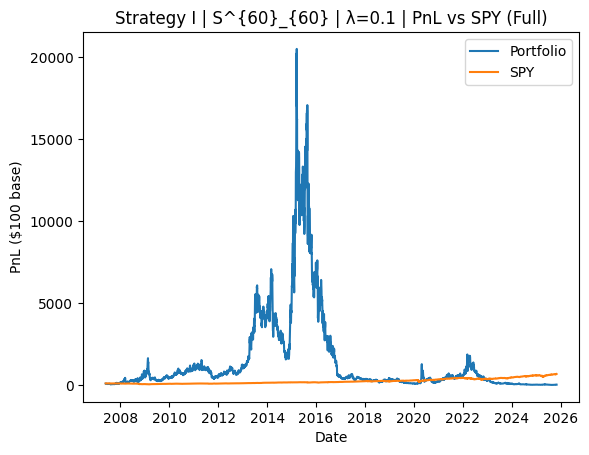

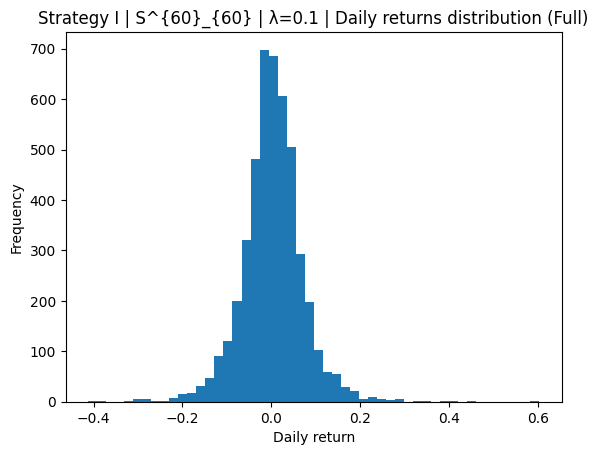

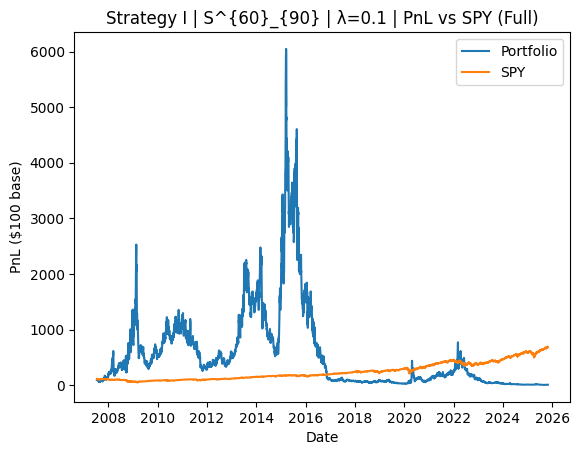

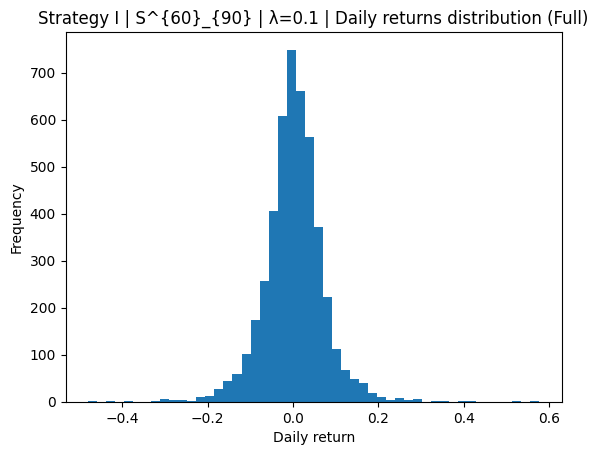

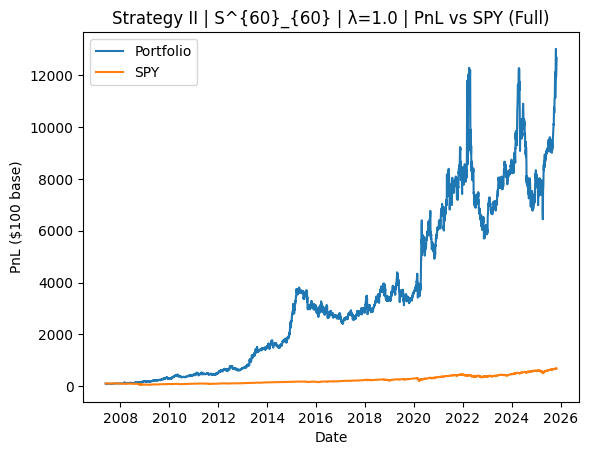

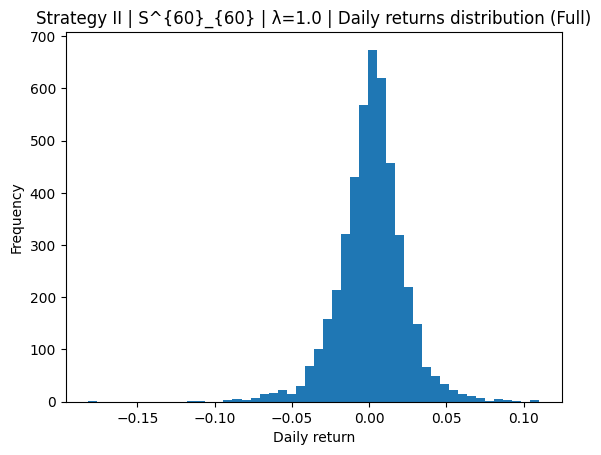

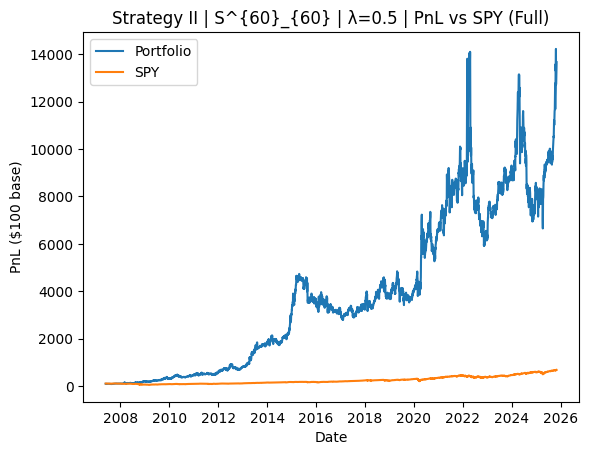

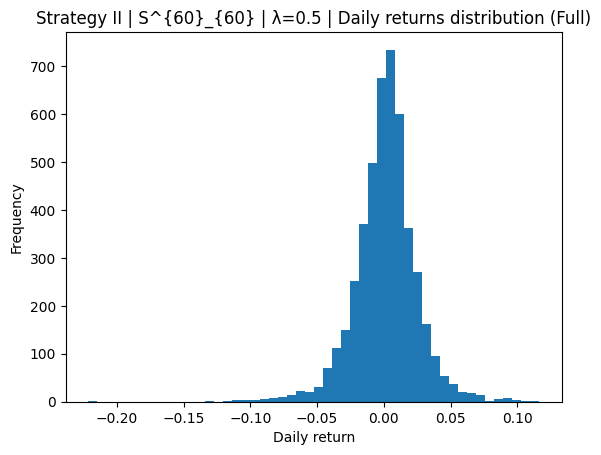

In [ ]:
from scipy.stats import norm

# Align RF and SPY to returns index
rf_daily = data["RF"].reindex(returns.index).dropna()
spy_ret = spy_returns_daily.reindex(returns.index).dropna()
spy_pnl = (100.0 * (1.0 + spy_ret).cumprod()).reindex(returns.index)

# 5 Sub Periods for Analysis
periods = {
    "Full": ("2007-03-01", "2025-10-31"),
    "P1_PreGFC": ("2007-03-01", "2008-06-30"),
    "P2_GFC": ("2008-07-01", "2009-03-31"),
    "P3_PostGFC_PreCovid": ("2009-04-01", "2019-12-31"),
    "P4_CovidShock": ("2020-01-01", "2020-06-30"),
    "P5_PostCovid": ("2020-07-01", "2025-10-31"),
}

ANN = 250  # assignment says to annualize all indicators (assuming 250 business days)


# Risk and Performance Helper Functions

def slice_period(s: pd.Series, start, end) -> pd.Series:
    if s is None:
        return pd.Series(dtype=float)
    return s.loc[pd.to_datetime(start):pd.to_datetime(end)]


def max_drawdown(pnl: pd.Series) -> float:
    pnl = pnl.dropna()
    if pnl.empty:
        return np.nan
    running_max = pnl.cummax()
    dd = pnl / running_max - 1.0
    return float(dd.min())


def max_10day_drawdown(pnl: pd.Series) -> float:
    pnl = pnl.dropna()
    if len(pnl) < 11:
        return np.nan
    vals = pnl.values
    worst = 0.0
    for i in range(len(vals) - 10):
        start = vals[i]
        trough = np.min(vals[i:i + 11])
        if start != 0:
            worst = min(worst, trough / start - 1.0)
    return float(worst)


def tracking_error_daily(port_r: pd.Series, spy_r: pd.Series) -> float:
    d = (port_r - spy_r).dropna()
    return float(d.std()) if len(d) > 1 else np.nan


def realized_beta(port_r: pd.Series, spy_r: pd.Series, rf: pd.Series) -> float:
    df = pd.concat([port_r, spy_r, rf], axis=1).dropna()
    if df.empty:
        return np.nan
    rp = df.iloc[:, 0] - df.iloc[:, 2]
    rm = df.iloc[:, 1] - df.iloc[:, 2]
    v = rm.var()
    return float(rp.cov(rm) / v) if v > 0 else np.nan


def hist_var_cvar(r: pd.Series, alpha=0.05):
    r = r.dropna()
    if r.empty:
        return np.nan, np.nan
    var = float(np.quantile(r, alpha))
    cvar = float(r[r <= var].mean()) if (r <= var).any() else np.nan
    return var, cvar


def modified_var_cornish_fisher(r: pd.Series, alpha=0.05):  # Corner-Fisher for modified VaR
    r = r.dropna()
    if len(r) < 30:
        return np.nan
    mu = r.mean()
    sig = r.std()
    if sig <= 0:
        return np.nan

    s = r.skew()
    k = r.kurt()  # excess kurtosis
    z = norm.ppf(alpha)

    # Cornish–Fisher expansion
    z_cf = (z + (1 / 6.0) * (z ** 2 - 1) * s + (1 / 24.0) * (z ** 3 - 3 * z) * k - (1 / 36.0) * (2 * z ** 3 - 5 * z) * (
            s ** 2))

    mvar = float(mu + sig * z_cf)
    return mvar


def summarize_series(port_r: pd.Series,
                     pnl: pd.Series,
                     spy_r: pd.Series,
                     rf: pd.Series,
                     alpha=0.05):
    port_r = port_r.dropna()
    pnl = pnl.dropna()

    # Default Output Keys
    out = {
        "cum_return": np.nan,

        "mean_daily_arith": np.nan,
        "mean_daily_geom": np.nan,
        "min_daily": np.nan,

        "mean_ann": np.nan,
        "vol_daily": np.nan,
        "vol_ann": np.nan,
        "sharpe_ann": np.nan,

        "skew": np.nan,
        "kurtosis": np.nan,

        "max_drawdown": np.nan,
        "max_10day_drawdown": np.nan,

        "mVaR_95_daily": np.nan,
        "CVaR_95_daily": np.nan,

        "beta_vs_spy": np.nan,
        "tracking_error_daily": np.nan,
        "tracking_error_ann": np.nan,
    }

    if port_r.empty or pnl.empty:
        return out

    # Cumulative return from pnl path
    out["cum_return"] = float(pnl.iloc[-1] / pnl.iloc[0] - 1.0)

    # Daily means (required)
    out["mean_daily_arith"] = float(port_r.mean())
    out["mean_daily_geom"] = float((1.0 + port_r).prod() ** (1.0 / len(port_r)) - 1.0)
    out["min_daily"] = float(port_r.min())

    # Volatility (daily + annual)
    vol_d = port_r.std()
    out["vol_daily"] = float(vol_d)
    out["vol_ann"] = float(vol_d * np.sqrt(ANN))

    # Annualized mean
    out["mean_ann"] = float(out["mean_daily_arith"] * ANN)

    # Sharpe (annualized)
    df_ex = pd.concat([port_r, rf], axis=1).dropna()
    if len(df_ex) > 1:
        ex = df_ex.iloc[:, 0] - df_ex.iloc[:, 1]
        ex_std = ex.std()
        out["sharpe_ann"] = float((ex.mean() / ex_std) * np.sqrt(ANN)) if ex_std > 0 else np.nan

    # Skewness and Kurtosis (excess kurtosis)
    out["skew"] = float(port_r.skew())
    out["kurtosis"] = float(port_r.kurt())

    # Drawdowns
    out["max_drawdown"] = max_drawdown(pnl)
    out["max_10day_drawdown"] = max_10day_drawdown(pnl)

    # Risk measures
    out["mVaR_95_daily"] = modified_var_cornish_fisher(port_r, alpha=alpha)
    _, cvar = hist_var_cvar(port_r, alpha=alpha)
    out["CVaR_95_daily"] = cvar

    # Beta and tracking error vs SPY
    out["beta_vs_spy"] = realized_beta(port_r, spy_r, rf)
    te_d = tracking_error_daily(port_r, spy_r)
    out["tracking_error_daily"] = te_d
    out["tracking_error_ann"] = float(te_d * np.sqrt(ANN)) if not np.isnan(te_d) else np.nan

    return out


# Summary tables (strategy/lookback/lambda/period) ----

def build_summary_table(portfolio_returns_dict, pnl_paths_dict, strategy_name: str):
    rows = []
    for lb_label in portfolio_returns_dict.keys():
        for lam in portfolio_returns_dict[lb_label].keys():
            r_all = portfolio_returns_dict[lb_label][lam]
            p_all = pnl_paths_dict[lb_label][lam]
            if r_all is None or p_all is None:
                continue

            for period_name, (start, end) in periods.items():
                r = slice_period(r_all, start, end)
                p = slice_period(p_all, start, end)
                r_spy = slice_period(spy_ret, start, end)
                rf_p = slice_period(rf_daily, start, end)

                metrics = summarize_series(r, p, r_spy, rf_p, alpha=0.05)
                rows.append({
                    "strategy": strategy_name,
                    "lookback": lb_label,
                    "lambda": float(lam),
                    "period": period_name,
                    **metrics
                })
    return pd.DataFrame(rows)


summary_I = build_summary_table(portfolio_returns_I, pnl_paths_I, "Strategy I")
summary_II = build_summary_table(portfolio_returns_II, pnl_paths_II, "Strategy II")
summary_all = pd.concat([summary_I, summary_II], ignore_index=True)
summary_all = summary_all.sort_values(["strategy", "lookback", "lambda", "period"]).reset_index(drop=True)

# Printing Required Columns for Analysis
required_cols = [
    "strategy", "lookback", "lambda", "period",
    "cum_return",
    "mean_daily_arith", "mean_daily_geom", "min_daily",
    "vol_ann", "sharpe_ann",
    "skew", "kurtosis",
    "max_10day_drawdown",
    "mVaR_95_daily", "CVaR_95_daily",
]

print("\n  SUMMARY TABLE")
print(summary_all[required_cols].to_string(index=False))

# Full Period Table
full_only = summary_all[summary_all["period"] == "Full"].copy()
compact_cols = [
    "strategy", "lookback", "lambda",
    "cum_return", "mean_ann", "vol_ann", "sharpe_ann",
    "max_drawdown", "max_10day_drawdown",
    "mVaR_95_daily", "CVaR_95_daily",
    "beta_vs_spy", "tracking_error_ann"
]
print("\n FULL SAMPLE PERIOD TABLE ")
print(full_only[compact_cols].sort_values(["strategy", "sharpe_ann"], ascending=[True, False]).to_string(index=False))


def summarize_spy_for_period(start, end, alpha=0.05):
    r = slice_period(spy_ret, start, end)
    pnl = slice_period(spy_pnl, start, end)
    rf = slice_period(rf_daily, start, end)
    return summarize_series(r, pnl, r, rf, alpha=alpha)


def config_label(lookback, lam):
    return f"{lookback}, λ={lam:g}"


def build_comparison_table(strategy_name, period_name="Full"):
    d = full_only[full_only["strategy"] == strategy_name].copy()
    start, end = periods[period_name]

    spy_metrics = summarize_spy_for_period(start, end, alpha=0.05)  # add SPY column metrics

    # Pick a few configs to display (top 3 by Sharpe)
    d = d.sort_values("sharpe_ann", ascending=False).head(3)

    rows = [
        ("Cum Return", "cum_return"),
        ("Mean Return (ann)", "mean_ann"),
        ("Volatility (ann)", "vol_ann"),
        ("Sharpe (ann)", "sharpe_ann"),
        ("Skewness", "skew"),
        ("Kurtosis", "kurtosis"),
        ("Max 10d DD", "max_10day_drawdown"),
        ("Max DD", "max_drawdown"),
        ("Modified VaR 95% (daily)", "mVaR_95_daily"),
        ("CVaR 95% (daily)", "CVaR_95_daily"),
        ("Beta vs SPY", "beta_vs_spy"),
        ("Tracking Error (ann)", "tracking_error_ann"),
    ]

    table = pd.DataFrame(index=[r[0] for r in rows])

    for _, row in d.iterrows():
        col = config_label(row["lookback"], row["lambda"])
        table[col] = [row[key] for _, key in rows]

    table["SPY"] = [spy_metrics[key] for _, key in rows]
    return table


print("\n COMPARISON TABLE (Strategy I, Full; top 3 configs + SPY)")
print(build_comparison_table("Strategy I", period_name="Full").to_string())

print("\n COMPARISON TABLE (Strategy II, Full; top 3 configs + SPY)")
print(build_comparison_table("Strategy II", period_name="Full").to_string())


# Plots (for top k configurations only, not all 36 plots)

def plot_pnl_vs_spy(pnl: pd.Series, title: str):
    pnl = pnl.dropna()
    if pnl.empty:
        return
    spy_aligned = spy_pnl.reindex(pnl.index).dropna()
    pnl_aligned = pnl.reindex(spy_aligned.index).dropna()

    plt.figure()
    plt.plot(pnl_aligned.index, pnl_aligned.values, label="Portfolio")
    plt.plot(spy_aligned.index, spy_aligned.values, label="SPY")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("PnL ($100 base)")
    plt.legend()
    plt.show()


def plot_return_hist(r: pd.Series, title: str):
    r = r.dropna()
    if r.empty:
        return
    plt.figure()
    plt.hist(r.values, bins=50)
    plt.title(title)
    plt.xlabel("Daily return")
    plt.ylabel("Frequency")
    plt.show()


TOP_K = 2  # how many configurations to plot per strategy (instead of doing every single one and haivng 36 plots)


def top_configs_for_strategy(strategy_name, k=2):
    d = full_only[full_only["strategy"] == strategy_name].copy()
    d = d.sort_values("sharpe_ann", ascending=False).head(k)
    return list(zip(d["lookback"].tolist(), d["lambda"].tolist()))


tops_I = top_configs_for_strategy("Strategy I", k=TOP_K)
tops_II = top_configs_for_strategy("Strategy II", k=TOP_K)

print(f"\nPlotting TOP {TOP_K} configurations by Sharpe for each strategy...")

for (lb_label, lam) in tops_I:
    pnl = pnl_paths_I[lb_label][lam]
    r = portfolio_returns_I[lb_label][lam]
    if pnl is not None and r is not None:
        plot_pnl_vs_spy(slice_period(pnl, *periods["Full"]),
                        f"Strategy I | {lb_label} | λ={lam} | PnL vs SPY (Full)")
        plot_return_hist(slice_period(r, *periods["Full"]),
                         f"Strategy I | {lb_label} | λ={lam} | Daily returns distribution (Full)")

for (lb_label, lam) in tops_II:
    pnl = pnl_paths_II[lb_label][lam]
    r = portfolio_returns_II[lb_label][lam]
    if pnl is not None and r is not None:
        plot_pnl_vs_spy(slice_period(pnl, *periods["Full"]),
                        f"Strategy II | {lb_label} | λ={lam} | PnL vs SPY (Full)")
        plot_return_hist(slice_period(r, *periods["Full"]),
                         f"Strategy II | {lb_label} | λ={lam} | Daily returns distribution (Full)")
